In [1]:
import os,re
import sys
import math
from copy import copy

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2
from venn import venn

import scanpy as sc
import anndata

import scanpy.external as sce
import gseapy


mpl.rcParams['figure.dpi'] = 50
mpl.rcParams['pdf.fonttype'] = 42
sc.settings.set_figure_params(facecolor=(0, 0, 0, 0), dpi=50, dpi_save=600)

sns.set_style({'axes.grid': False})

import warnings
warnings.filterwarnings('ignore')


/home/xuq44/miniconda3/envs/scpy/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sc.settings.figdir = f'/home/xuq44/projects/hgioa/revision2/figures'


In [3]:
import sys
sys.path.append('/home/xuq44/projects/hgioa/revision/scripts/cytokines/scripts')
from scattermap import *


# sys.path.append('/home/xuq44/projects/hgioa/revision/scripts/scpoli/')
# from scpoli_map import *
# from scpoli_de import *


In [4]:
project_dir="/home/xuq44/projects/hgioa/data/revision2"
out_dir='new_20240718'
fig_dir = "/home/xuq44/projects/hgioa/revision2/figures"

In [7]:
gns = copy(mpl.cm.Blues)
gns.set_under("lightgray")

plate_level_all0 = pd.read_csv(f"/home/xuq44/projects/hgioa/data/revision/scripts/db/gut_scpoli_color.txt",
                sep='\t', header=None, index_col=0)
plate_level_all0['names']=plate_level_all0.index
plate_level_all = plate_level_all0.to_dict()[1]
plate_level_all['nan']='gray'

all_samples_color = {"IHBDECO082_001_ctr_2_3":'gray', 
                     "IHBDECO082_002_M_cells":'#00a0e1', 
                     "IHBDECO082_003_Tuft_cells":'#466eb4', 
                     "IHBDECO082_004_viral":'#e6a532', 
                     "IHBDECO082_005_inflammation":'#d7642c', 
                     "IHBDECO082_006_ctr_4_5":'gray',
                     "ctr":'gray', 
                     "M":'#00a0e1', 
                     "Tuft":'#466eb4', 
                     "viral":'#e6a532', 
                     "inflammation":'#d7642c'                    
                    }
plate_level_all = plate_level_all|all_samples_color


In [8]:
os.environ["R_HOME"] = "/home/xuq44/scratch/miniconda3/envs/r/lib/R" 
import rpy2
from rpy2.robjects import r


%load_ext rpy2.ipython

In [9]:
%%R -i plate_level_all0 

col_list <- setNames(plate_level_all0$`1`, plate_level_all0$names)

library(ComplexHeatmap)
library(ggplot2)
library(ggrepel)
library(ggtext)
library(ggpubr)
library(patchwork)

set.seed(1)

R[write to console]: Loading required package: grid

R[write to console]: ========================================
ComplexHeatmap version 2.14.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))




In [10]:
sub_samples6 = ["IHBDECO082_006_ctr_4_5", "IHBDECO082_004_viral", "IHBDECO082_005_inflammation"]

In [12]:
adata_list=[]
dist_df0 = pd.DataFrame()

for sample in sub_samples6:
    data_dir = f"/home/xuq44/projects/hgioa/data/revision/results/cytokines/sc2heoca_res_qc/{sample}"
    adata0 = sc.read_h5ad(f"{data_dir}/{sample}.h5ad")
    adata_list.append(adata0)
    
    dist_df0 = pd.concat([dist_df0, adata0.obs[['sample_id','predict_level_2','mean_dist']]])

adata = anndata.AnnData.concatenate(*adata_list, join='outer', fill_value=0)


In [13]:
adata

AnnData object with n_obs × n_vars = 8267 × 3000
    obs: 'pct_counts_mt', 'n_genes_by_counts', 'batch', 'tissue', 'level_1', 'level_2', 'level_3', 'sample_id', 'conditions_combined', 'predict_level_1', 'predict_level_2', 'predict_level_3', 'mean_dist', 'predict_detail_tissue'
    var: 'gene_ids-0', 'feature_types-0', 'n_cells_by_counts-0-0', 'mean_counts-0-0', 'pct_dropout_by_counts-0-0', 'total_counts-0-0', 'n_cells_by_counts-0-1', 'mean_counts-0-1', 'pct_dropout_by_counts-0-1', 'total_counts-0-1', 'n_cells_by_counts-0-2', 'mean_counts-0-2', 'pct_dropout_by_counts-0-2', 'total_counts-0-2'
    obsm: 'X_umap', 'scpoli_latent'
    layers: 'counts'

In [17]:
# sc.pl.umap(adata, color=["predict_level_2","mean_dist","sample_id"], ncols=5, frameon=False, size=2)


In [14]:
# adata_ent = adata[adata.obs.predict_level_2=='stem cells'].copy()
adata_ent = adata.copy()

In [81]:
# adata_ent.obs['isnew']='no'
# adata_ent.obs.loc[adata_ent.obs.mean_dist>0.2064294221138754, 'isnew']='yes'

In [15]:
adata_ent1 = adata_ent[adata_ent.obs.sample_id.isin(['IHBDECO082_006_ctr_4_5',
                                        'IHBDECO082_005_inflammation'])].copy()

sc.tl.rank_genes_groups(adata_ent1, 'sample_id', method='wilcoxon', key_added = "wilcoxon")

wc2 = sc.get.rank_genes_groups_df(adata_ent1, group='IHBDECO082_005_inflammation', key='wilcoxon')
wc2['-log10p'] = -np.log10(wc2.pvals_adj)
wc2.index=wc2.names


In [16]:
adata_ent2 = adata_ent[adata_ent.obs.sample_id.isin(['IHBDECO082_006_ctr_4_5',
                                        'IHBDECO082_004_viral'])].copy()

sc.tl.rank_genes_groups(adata_ent2, 'sample_id', method='wilcoxon', key_added = "wilcoxon")

wc = sc.get.rank_genes_groups_df(adata_ent2, group='IHBDECO082_004_viral', key='wilcoxon')
wc['-log10p'] = -np.log10(wc.pvals_adj)
wc.index=wc.names



In [200]:
# adata_ent2

In [23]:

# sc.tl.rank_genes_groups(adata_ent2, 'sample_id', method='logreg',key_added = "logreg")

In [20]:
# sc.pl.rank_genes_groups(adata_ent2, n_genes=25, sharey=False, key = "wilcoxon")


In [21]:
# sc.get.rank_genes_groups_df(adata_ent2, group='IHBDECO082_004_viral', key='logreg')

In [22]:
de_res = pd.merge(wc, wc2, left_index=True, right_index=True)

de_res['condition']=None
de_res.loc[de_res.scores_x>10, 'condition'] = 'Viral'
de_res.loc[de_res.scores_y>10, 'condition'] = 'Infla.'
de_res.loc[(de_res.scores_x>10)&(de_res.scores_y>10), 'condition'] = 'Overlap'
de_res.loc[(de_res.scores_x<-20)&(de_res.scores_y<-20), 'condition'] = 'HEOCA'

show_genes = de_res[(de_res.condition=='Viral')&(de_res.scores_x>55)].index.tolist() + \
            de_res[(de_res.condition=='Infla.')&(de_res.scores_y>30)].index.tolist() + \
            de_res[(de_res.condition=='Overlap')&((de_res.scores_x>55)|\
                                                                  (de_res.scores_y>30))].index.tolist() +\
            de_res[(de_res.condition=='HEOCA')&((de_res.scores_x<-50)&\
                                                                (de_res.scores_y<-45))].index.tolist()

remove_genes=['XIST']
add_genes = ['OAS1', 'OAS2', 'OAS3']
show_genes = [i for i in show_genes if i not in remove_genes]+add_genes


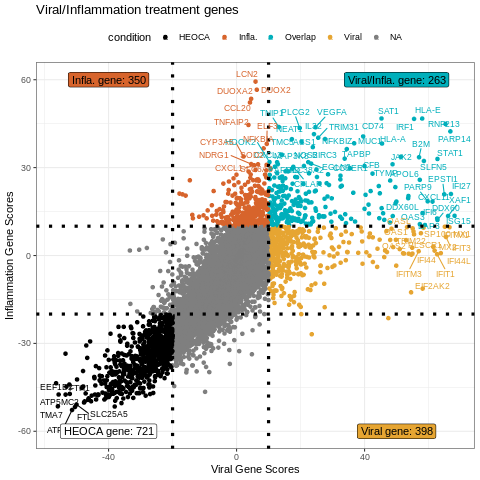

In [23]:
%%R -i de_res -i show_genes -i fig_dir

theme_set(
  theme_bw() +
    theme(legend.position = "top")
  )

.labs <- ifelse(rownames(de_res) %in% unlist(show_genes), rownames(de_res), "")

p <- ggplot(de_res, aes(x=scores_x, y=scores_y)) + 
            geom_point(aes(color = condition))+
            scale_color_manual(values = c("black", "#d7642c", "#00AFBB", "#e6a532"))+
            geom_vline(xintercept=10, linetype="dotted", color = "black", size=1.5)+
            geom_hline(yintercept=10, linetype="dotted", color = "black", size=1.5)+
            geom_vline(xintercept=-20, linetype="dotted", color = "black", size=1.5)+
            geom_hline(yintercept=-20, linetype="dotted", color = "black", size=1.5)+
            geom_text_repel(aes(label=.labs,  color = condition), size=3, max.overlaps = Inf)+
            annotate(geom="label", fill="#e6a532", x = 50, y = -60, label = paste0('Viral gene: ', 
                                nrow(de_res[de_res$condition %in% 'Viral',])))+
            annotate(geom="label", fill="#00AFBB", x = 50, y = 60, label = paste0('Viral/Infla. gene: ', 
                                nrow(de_res[de_res$condition %in% 'Overlap',])))+
            annotate(geom="label", fill="#d7642c", x = -40, y = 60, label = paste0('Infla. gene: ', 
                                nrow(de_res[de_res$condition %in% 'Infla.',])))+
            annotate(geom="label", fill="white", x = -40, y = -60, label = paste0('HEOCA gene: ', 
                                nrow(de_res[de_res$condition %in% 'HEOCA',])))+
            labs(title="Viral/Inflammation treatment genes", 
                 x ="Viral Gene Scores", y = "Inflammation Gene Scores")

# pdf(paste0(fig_dir, '/cytokines_degenes_2ctr.pdf'))
print(p)
# dev.off()


In [135]:
de_res

,names_x,scores_x,logfoldchanges_x,pvals_x,pvals_adj_x,-log10p_x,names_y,scores_y,logfoldchanges_y,pvals_y,pvals_adj_y,-log10p_y,condition
names,,,,,,,,,,,,,
ISG15,ISG15,68.128105,7.913828,0.0,0.0,inf,ISG15,13.555284,1.820480,7.372678e-42,4.902417e-41,40.309590,Overlap
IFI27,IFI27,66.983994,6.568898,0.0,0.0,inf,IFI27,20.993275,2.129898,7.555574e-98,1.048144e-96,95.979579,Overlap
PARP14,PARP14,66.810539,4.904418,0.0,0.0,inf,PARP14,42.361794,3.375798,0.000000e+00,0.000000e+00,inf,Overlap
MX1,MX1,66.547440,7.260283,0.0,0.0,inf,MX1,9.654604,2.012028,4.699730e-22,2.149826e-21,20.667597,Viral
XAF1,XAF1,66.096039,8.794659,0.0,0.0,inf,XAF1,13.492476,4.517488,1.731862e-41,1.145502e-40,39.941004,Overlap
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ATP5MC2,ATP5MC2,-53.424835,-2.038968,0.0,0.0,inf,ATP5MC2,-47.474697,-2.702291,0.000000e+00,0.000000e+00,inf,HEOCA
TPT1,TPT1,-53.453915,-1.418814,0.0,0.0,inf,TPT1,-33.508942,-1.332091,3.570907e-246,1.827249e-244,243.738202,HEOCA
EEF1B2,EEF1B2,-55.605324,-2.172243,0.0,0.0,inf,EEF1B2,-47.452675,-2.326951,0.000000e+00,0.000000e+00,inf,HEOCA


In [25]:
allupgenes={}
alldowngenes={}
coef_cutoff = 0.2

project_dir="/home/xuq44/projects/hgioa/data/revision"
data_dir = f'{project_dir}/results/cytokines/sc2heoca_res/'
sub_samples6 = ["IHBDECO082_006_ctr_4_5", "IHBDECO082_004_viral", "IHBDECO082_005_inflammation"]

de_genes4 = pd.read_csv(f'{data_dir}/{sub_samples6[1]}/{sub_samples6[1]}_degenes.txt', 
            index_col=0, sep='\t')

de_genes5 = pd.read_csv(f'{data_dir}/{sub_samples6[2]}/{sub_samples6[2]}_degenes.txt', 
            index_col=0, sep='\t')

allupgenes['Viral'] = set(de_genes4[(de_genes4.coef>coef_cutoff)].index.tolist())
allupgenes['Infla.'] = set(de_genes5[(de_genes5.coef>coef_cutoff)].index.tolist())
alldowngenes['all'] = set(de_genes4[(de_genes4.coef<-coef_cutoff)&(de_genes5.coef<-coef_cutoff)].index.tolist())


In [140]:
de_genes4['logp'] = np.log10(de_genes4.padj+1)
# .log10p_x

In [195]:
aaa = pd.merge(de_res, de_genes4, left_index=True, right_index=True)[['scores_x','logfoldchanges_x','coef']]


In [167]:
bbb = pd.merge(de_res, de_genes5, left_index=True, right_index=True)[['scores_y','coef']]


<Axes: xlabel='scores_x', ylabel='coef'>

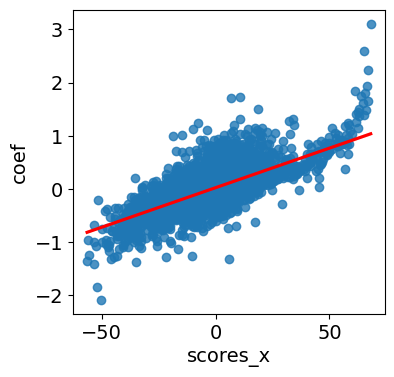

In [95]:
sns.regplot(aaa, x='scores_x', y='coef', line_kws=dict(color="r"))

<Axes: xlabel='scores_y', ylabel='coef'>

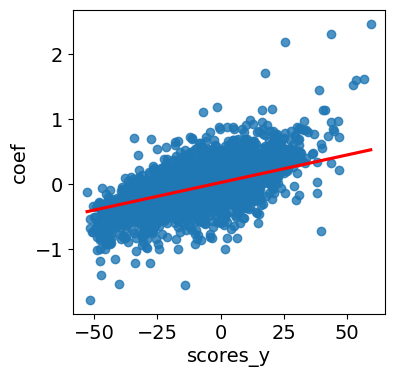

In [98]:
sns.regplot(bbb, x='scores_y', y='coef', line_kws=dict(color="r"))

In [156]:
aaa['tt'] = 'na'
aaa.loc[aaa.scores_x > 10,'tt']='aa'
aaa.loc[aaa.scores_x < -20,'tt']='bb'


In [154]:
bbb['tt'] = 'na'
bbb.loc[bbb.scores_y > 10,'tt']='aa'
bbb.loc[bbb.scores_y < -20,'tt']='bb'


In [168]:
%%R -i bbb -i aaa
library(patchwork)

p1 <- ggscatter(bbb,x='scores_y', y='coef', color='tt', palette = "jco",
                   add = "reg.line", conf.int = TRUE)+ stat_cor(aes(color = tt))

p2 <- ggscatter(aaa, y='coef', x='scores_x', color='tt', palette = "jco",
                   add = "reg.line", conf.int = TRUE)+ stat_cor(aes(color = tt))

p1

Error in `stat_cor()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 3rd layer.
Caused by error in `FUN()`:
! object 'tt' not found
Run `rlang::last_trace()` to see where the error occurred.


RRuntimeError: Error in stat_cor(aes(color = tt)) : 
ℹ Error occurred in the 3rd layer.
Caused by error in `FUN()`:
! object 'tt' not found


In [230]:
show_genes = bbb.sort_values('coef').tail(20).index.tolist()+bbb.sort_values('scores_y').tail(20).index.tolist()

In [231]:
%%R -i bbb -i aaa -i show_genes

.labs <- ifelse(rownames(bbb) %in% unlist(show_genes), rownames(bbb), "")

p1 <- ggplot(bbb, aes(x=scores_y, y=coef)) + 
            geom_point(aes(color = 'blue'))+stat_smooth(color='black')+
            scale_color_manual(values = c("#d7642c"))+
            geom_text_repel(aes(label=.labs), size=3, max.overlaps = Inf)+
            labs(title="Inflammation treatment genes", 
                 x ="Compare to ctrl", y = "Compare to HEOCA")



pdf(paste0(fig_dir, '/cytokines_degenes_infla_compare_2ctr.pdf'))
print(p1)
dev.off()


`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
png 
  2 


In [190]:
bbb.loc['LYZ']

scores_y    2.728987
coef        0.877196
Name: LYZ, dtype: float64

In [232]:
show_genes = aaa.sort_values('coef').tail(20).index.tolist()+aaa.sort_values('scores_x').tail(20).index.tolist()

In [234]:
%%R -i bbb -i aaa -i show_genes

.labs <- ifelse(rownames(aaa) %in% unlist(show_genes), rownames(aaa), "")

p1 <- ggplot(aaa, aes(x=scores_x, y=coef)) + 
            geom_point(aes(color = 'blue'))+stat_smooth(color='black')+
            scale_color_manual(values = c("#e6a532"))+
            geom_text_repel(aes(label=.labs), size=3, max.overlaps = Inf)+
            labs(title="Viral treatment genes", 
                 x ="Compare to ctrl", y = "Compare to HEOCA")


pdf(paste0(fig_dir, '/cytokines_degenes_viral_compare_2ctr.pdf'))
print(p1)
dev.off()


`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
png 
  2 


In [203]:
adata_ent2_obs = adata_ent2.obs

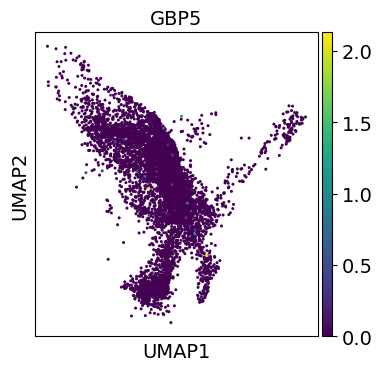

In [207]:
sc.pl.umap(adata_ent2,color='GBP5')
# ['GBP7']

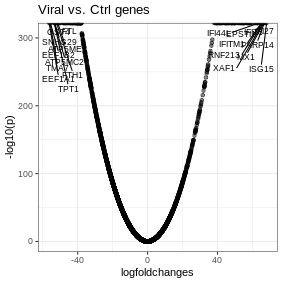

In [32]:
%%R -i wc -w 10 -h 10 -u cm

show_genes <- c(rownames(head(wc,10)), 
                  rownames(tail(wc,10)))

theme_set(
  theme_bw() +
    theme(legend.position = "top")
  )

.labs1 <- ifelse(rownames(wc) %in% unlist(show_genes), rownames(wc), "")

p1 <- ggplot(wc, aes(x=scores, y= `-log10p`))+
    geom_point(size = 1.5, alpha = 0.5)+
    geom_text_repel(aes(label=.labs1), size=3, max.overlaps = Inf, point.padding = NA)+
    labs(title="Viral vs. Ctrl genes", 
         x ="logfoldchanges", y = "-log10(p)") +
    theme(legend.position = "none")

p1

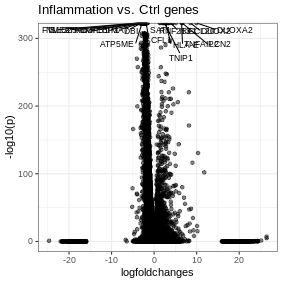

In [278]:
%%R -i wc2 -w 10 -h 10 -u cm

show_genes <- c(rownames(head(wc2,10)), 
                  rownames(tail(wc2,10)))

theme_set(
  theme_bw() +
    theme(legend.position = "top")
  )

.labs1 <- ifelse(rownames(wc2) %in% unlist(show_genes), rownames(wc2), "")

p2 <- ggplot(wc2, aes(x=logfoldchanges, y= `-log10p`))+
    geom_point(size = 1.5, alpha = 0.5)+
    geom_text_repel(aes(label=.labs1), size=3, max.overlaps=Inf, point.padding=NA)+
    labs(title="Inflammation vs. Ctrl genes", 
         x ="logfoldchanges", y = "-log10(p)") +
    theme(legend.position = "none")

p2

In [282]:
for i in wc2[(wc2.pvals_adj<0.01)&(wc2.logfoldchanges>0)].names:
    print(i)

LCN2
DUOX2
DUOXA2
CCL20
SAT1
HLA-E
IRF1
RNF213
TNFAIP2
TNIP1
VEGFA
PLCG2
PARP14
IL32
CD74
TRIM31
NFKBIZ
NEAT1
ASS1
MUC1
HLA-A
ELF3
BIRC3
NFKBIA
TAPBP
TMC5
CYP3A5
JAK2
B2M
CCSER1
STAT1
SLFN5
HOOK2
NOS2
CXCL3
EGLN3
NDRG1
TYMP
MAP3K8
SOD2
SLC6A8
CXCL1
SLC38A2
CFB
AFMID
CFLAR
HLA-F
WSB1
CROCC
CDC42SE2
BTG1
PFKFB3
P4HA1
MYH14
ATP1B1
ICAM1
ZNF292
PSMB10
FGD6
HHLA2
ATP10B
ZC3H12A
TNFAIP3
FNDC3B
PPP1R10
LLGL2
LINC01138
PTPRR
RRBP1
RHBDF2
SEMA4B
ARRDC3
KDM4B
ANGPTL4
ERRFI1
MYO15B
CXCL2
OPTN
PNCK
APOL6
HEXIM1
CXCL8
PIGR
PPP1R15A
HLA-B
SQSTM1
ANKRD37
TMPRSS2
XDH
IER3
RBCK1
DNM2
VNN1
HLA-DRA
TCF7L2
SOCS1
TPCN1
XKR9
LAMB3
TENT5C
ANKRD11
LMO7
CSKMT
POLR2A
GSDMB
CCL28
GBP2
LDLR
XRN1
MXD1
ID2
SAA1
INTS6
SMAD3
TEX14
ZBTB7A
TGM2
GOLGB1
LINC00910
SAV1
RIN2
GSDMD
ERN1
RIPK1
HILPDA
NLRC5
PMAIP1
ARGLU1
ETV6
IFNGR1
PLK2
MYO7B
ERO1A
SLC37A1
MACF1
SAA2
TNFRSF10D
RGS2
BATF2
GADD45B
LINC02649
ANKRD36C
IRF9
TRIO
CDC42EP5
SGPP2
CDCP1
SDC4
IFI27
EPSTI1
SLC44A4
CSRNP2
PARP8
CDHR2
MVD
TNFRSF14-AS1
JUNB
PRRC2C
ATF3
FR

In [262]:
wc[wc.names.isin(['STAT1','ISG15','IFIT1','OAS1'])]

,names,scores,logfoldchanges,pvals,pvals_adj,-log10p
names,,,,,,
ISG15,ISG15,68.128105,7.913828,0.0,0.0,inf
STAT1,STAT1,62.772701,3.946873,0.0,0.0,inf
IFIT1,IFIT1,62.661232,11.445454,0.0,0.0,inf
OAS1,OAS1,55.276878,4.197784,0.0,0.0,inf


In [18]:
# sc.pl.umap(adata_ent, color=["predict_level_2","isnew","sample_id"], ncols=5, frameon=False, size=100)


In [24]:
genes=['IFI44','IFIT1','DUOX2','TNFAIP2']
forplot = adata_ent.raw.to_adata().to_df()[genes]
# forplot.columns=['exp']
forplot['isnew'] = adata_ent.obs.isnew
forplot['sample_id'] = adata_ent.obs.sample_id
# forplot = pd.melt(forplot, id_vars=['sample_id','isnew'], value_vars=genes)




In [26]:
forplot.groupby(['sample_id','isnew']).mean()

IFI44     IFIT1     DUOX2   TNFAIP2
sample_id                   isnew                                        
IHBDECO082_004_viral        no     1.438911  2.274840  0.454186  0.102634
                            yes    1.711892  2.301698  0.440609  0.078984
IHBDECO082_005_inflammation no     0.035089  0.025914  2.540998  0.963145
                            yes    0.025639  0.133710  2.520980  1.368734
IHBDECO082_006_ctr_4_5      no     0.009231  0.028714  0.188931  0.076433
                            yes    0.000000  0.096061  0.061885  0.093171

In [150]:
adata_ent[adata_ent.obs.sample_id=='IHBDECO082_006_ctr_4_5'].obs.quantile(0.95)

pct_counts_mt          17.131289
n_genes_by_counts    7614.600000
mean_dist               0.238628
Name: 0.95, dtype: float64

In [95]:
bins = np.linspace(0, 0.4, 10)

In [139]:
genes=['IFI44','IFIT1','DUOX2','TNFAIP2']
forplot = adata_ent.raw.to_adata().to_df()[genes]
# forplot.columns=['exp']
forplot['mean_dist'] = adata_ent.obs.mean_dist
forplot['sample_id'] = adata_ent.obs.sample_id
forplot = forplot[forplot.mean_dist<0.4]
forplot = pd.melt(forplot, id_vars=['sample_id','mean_dist'], value_vars=genes)

forplot['binned'] = pd.cut(forplot['mean_dist'], [bins])

# sns.lmplot(data=forplot, x='mean_dist', y='IFI44', hue='sample_id')

In [108]:
# forplot.groupby(['sample_id','binned']).mean()

In [109]:
# sns.boxplot(data=forplot, x='binned', y='exp', hue='sample_id')

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


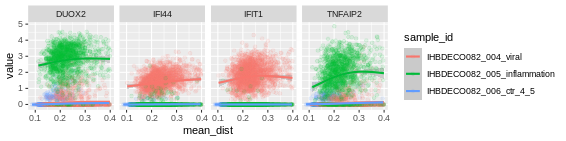

In [142]:
%%R -i forplot -w 20 -h 5 -u cm
library(ggplot2)

ggplot(forplot, aes(x=mean_dist, y=value, color=sample_id)) + 
  geom_point(alpha = 0.1)+
  geom_smooth()+facet_grid(. ~ variable)

In [32]:
forplot['s']='na'

forplot.loc[forplot.mean_dist>0.15, 's'] = 'large'
forplot.loc[forplot.mean_dist<0.15, 's'] = 'small'


In [152]:
forplot.groupby(['sample_id']).mean()

,mean_dist,value
sample_id,,
IHBDECO082_004_viral,0.237362,0.823191
IHBDECO082_005_inflammation,0.226713,1.136609
IHBDECO082_006_ctr_4_5,0.179451,0.020449


In [29]:
forplot

,STAT1,mean_dist,sample_id,s
AAACCCAAGATAGCTA-1-0-0,0.290179,0.165007,IHBDECO082_006_ctr_4_5,large
AAACCCACATCTTAGG-1-0-0,0.545291,0.154821,IHBDECO082_006_ctr_4_5,large
AAACCCATCCTACCGT-1-0-0,0.653986,0.204525,IHBDECO082_006_ctr_4_5,large
AAACGAAAGACATCAA-1-0-0,0.902666,0.167526,IHBDECO082_006_ctr_4_5,large
AAAGAACCAGGTGTGA-1-0-0,0.000000,0.155478,IHBDECO082_006_ctr_4_5,large
...,...,...,...,...
TTTGGAGCACCCAACG-1-0-2,2.348200,0.238132,IHBDECO082_005_inflammation,large
TTTGGAGCATTAGGAA-1-0-2,0.000000,0.218009,IHBDECO082_005_inflammation,large
TTTGGAGGTCAGGTAG-1-0-2,2.735865,0.309353,IHBDECO082_005_inflammation,large
TTTGGAGGTCCAGCAC-1-0-2,1.046648,0.268751,IHBDECO082_005_inflammation,large


In [ ]:
color_data = get_cellprop_res(adata6, sub_samples6, max_cts=5)
color_data['condition'] = [i.split('_')[2] for i in color_data.sample_id]


In [ ]:
%%R -i color_data -i fig_dir

sam_order <- c("ctr", "viral", "inflammation")
color_data$condition <- factor(color_data$condition, levels = sam_order)

size_mean <- aggregate(color_data$size, list(color_data$predict_level_2), FUN=mean)
size_mean <- size_mean[order(size_mean$x, decreasing = TRUE), ]
ct_order <- size_mean[,1]
color_data$predict_level_2 <- factor(color_data$predict_level_2, levels = ct_order)

p <- ggplot(color_data, aes(x=condition, y=predict_level_2))+ 
            geom_point(aes(size=size, color=color))+
            scale_colour_gradient2(low = "black", mid = "red",high = "orange", 
                                   midpoint=0.3, limits=c(0, 0.4))+
            theme_linedraw()

pdf(paste0(fig_dir, "/proli_distance.pdf"), 4, 3)
print(p)
dev.off()


In [ ]:
color_data = get_cellprop_res(adata6, sub_samples6, max_cts=10)
color_data['condition'] = [i.split('_')[2] for i in color_data.sample_id]

forplot1 = color_data.set_index('sample_id').pivot(columns='predict_level_2', values='size')
forplot1 = forplot1.loc[sub_samples6][::-1]

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
forplot1.plot.barh(stacked=True, ax=ax, width=0.95, color=plate_level_all, legend=False)
# fig.savefig(f"{fig_dir}/proli_distance_bar.pdf", bbox_inches="tight")


In [ ]:
forplot1

In [ ]:
adata6_obs = adata6.obs
adata6_obs['sample_name'] = [i.split('_')[2] for i in adata6_obs.sample_id]


In [ ]:
adata6_obs['sample_name'].unique()

In [ ]:
%%R -i adata6_obs -i fig_dir -w 20 -h 20 -u cm
library(ggplot2)
library(ggpubr)
library(patchwork)


my_comparisons <- list(
                       c('ctr', 'viral'),
                        c('ctr', 'inflammation')
                      )
adata6_obs[, 'sample_name'] <- factor(adata6_obs[, 'sample_name'], levels=
                                      c('ctr', 'viral', 'inflammation'))


sub_plot <- function(celltype, my_comparisons, labely){
    labelys=c()
    for (i in seq(0, length(my_comparisons)-1, 1)){
        labelys<-c(labelys, labely+(labely/4*i))
    }

    p <- ggplot(adata6_obs[adata6_obs$predict_level_2==celltype,], aes(sample_name, mean_dist, fill=sample_name))+
                 geom_boxplot(outliers=FALSE) +
                 scale_fill_manual(values = col_list) + 
                 expand_limits(ymax=labely+labely/2+labely/10*i)+
                 stat_compare_means(comparisons=my_comparisons, label = "p.format", 
                                    label.y=labelys) + 
                 ggtitle(celltype) + xlab("") + ylab("")+
                 theme_bw()+ rotate_x_text(45)+ theme(legend.position = "none")
    p
}


p1 <- sub_plot('stem cells', my_comparisons, 0.41)
p2 <- sub_plot('goblet cells', my_comparisons, 0.52)
p3 <- sub_plot('enterocytes', my_comparisons, 0.52)
p4 <- sub_plot('enteroendocrine cells', my_comparisons, 1.4)

ggarrange(p1, p2, p3, p4, ncol = 4, nrow = 1) %>% 
    ggexport(filename=paste0(fig_dir, '/proli_distance_box.pdf'), width=6, height=3.5)
